In [ ]:
import os
from skimage import color, io, measure, img_as_ubyte, segmentation, morphology
from skimage.measure import profile_line
from skimage.transform import rescale, resize
import matplotlib.pyplot as plt
import numpy as np
import pydicom as dicom
import math
from skimage.util import img_as_float
from skimage.util import img_as_ubyte
from skimage.filters import (
    threshold_otsu,
    median,
    gaussian,
    prewitt_h,
    prewitt_v,
    prewitt,
)
from skimage.color import rgb2gray, label2rgb
from scipy.ndimage import correlate
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import norm
from scipy.spatial import distance

## Kidneys

In [3]:
in_dir = "kidneys/"
im_name = "1-189.dcm"
ds = dicom.dcmread(in_dir + im_name)
ds

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 194
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.826.0.1.3680043.2.1125.1.49542551555698270443638847188521538
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002,0013) Implementation Version Name         SH: 'dcm4che-1.4.35'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.826.0.1.3680043.2.1125.1.49542551555698270443638847188521538
(0008,0020) Study Date                   

In [4]:
im = ds.pixel_array

In [68]:
import pydicom
import numpy as np
from scipy.ndimage import label
from skimage.measure import regionprops
from skimage.morphology import disk, closing
# Create binary image with thresholding
binary_im = (im >= 100) & (im <= 250).astype(np.uint8)

# Perform BLOB analysis
labeled_im, num_blobs = label(binary_im)
props = regionprops(labeled_im)

# Filter BLOBS based on perimeter and area
min_perimeter = 400
max_perimeter = 600
max_area = 5000
min_area = 1000
kidney_blobs = []

for prop in props:
    area = prop.area  # Number of pixels in the BLOB
    perimeter = prop.perimeter  # Perimeter of the BLOB
    if min_perimeter <= perimeter <= max_perimeter and min_area <= area <= max_area:
        kidney_blobs.append(prop)

# Create a binary image with only the kidney BLOBS
kidney_mask = np.zeros_like(binary_im)
for blob in kidney_blobs:
    kidney_mask[labeled_im == blob.label] = 1

# Apply morphological closing
structuring_element = disk(3)
kidney_mask_closed = closing(kidney_mask, structuring_element)

In [69]:
kidney_mask_closed.shape

(512, 512)

When all BLOBs are found and the area and the perimeter are computed
for all of them. We set the minimum perimeter to 400 and the maximum
perimeter to 600. The maximum BLOB area is set to 5000. What should
the minimum BLOB area be set to, so only the kidneys are found?

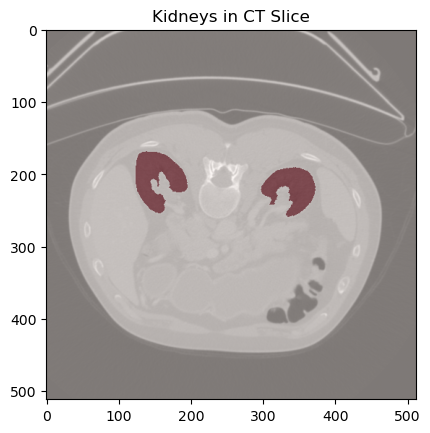

In [70]:
import matplotlib.pyplot as plt

plt.imshow(ds.pixel_array, cmap="gray")
plt.imshow(kidney_mask_closed, cmap="Reds", alpha=0.5)
plt.title("Kidneys in CT Slice")
plt.show()

## Ans : 1000

An expert has drawn an approximate outline of the kidneys.
You compare your segmentation (after the morphological closing) with
the expert segmentation using the DICE score. What is the DICE score?

In [8]:
ground_truth_img = io.imread(in_dir + "kidneys_gt.png")
gt_bin = ground_truth_img > 0
dice_score = 1 - distance.dice(kidney_mask_closed.ravel(), gt_bin.ravel())
print(f"DICE score {dice_score}")

DICE score 0.9095344298856983


## ANS: Between 0.90 and 0.95

One pixel in the image corresponds to a physical size of 0.78 mm x 0.78
mm.
When the kidneys have been isolated and the morphological closing is
performed, the total area of the kidneys is computed. It is:

In [9]:
np.count_nonzero(kidney_mask_closed)

6531

## Ans: Between 35 and 45 cm^2

When the kidneys have been isolated and the morphological closing is
performed, the Hounsfield units in the original image under the
segmentation mask is sampled. What is the median HU value?

In [10]:
hu_values = im[kidney_mask_closed == 1]

# Compute median HU
median_hu = np.median(hu_values)
print(f"Median HU value: {median_hu}")

Median HU value: 165.0


## Ans: 165

/tmp/ipykernel_30749/2539884133.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im, vmin=50, vmax=300, cmap="gray")
/tmp/ipykernel_30749/2539884133.py:5: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


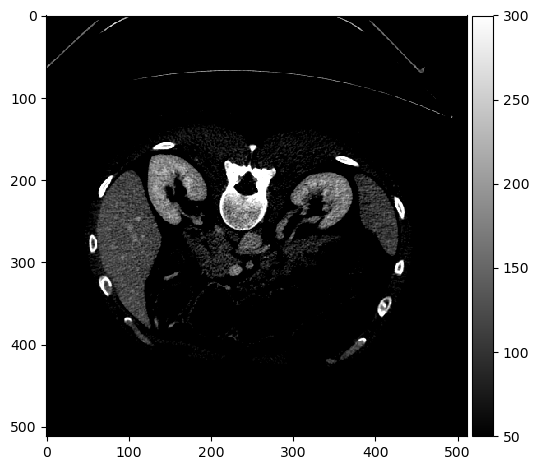

/tmp/ipykernel_30749/2539884133.py:12: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(vb_label_colour)
/tmp/ipykernel_30749/2539884133.py:14: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


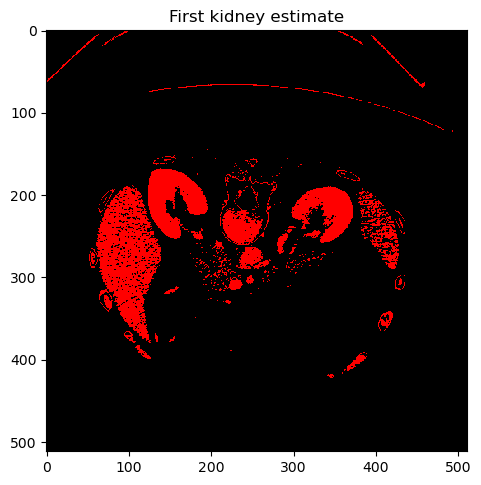

Number of labels: 391
Answer: Minimum area 2000
Area 3503.0 Perimeter 439.65284963613556
Area 2807.0 Perimeter 509.56453788156705
Answer: Min area 1 and max area 7866


In [71]:
in_dir = "kidneys/"
im_name = "1-189.dcm"

io.imshow(im, vmin=50, vmax=300, cmap="gray")
io.show()

min_hu = 100
max_hu = 250

bin_img = (im > min_hu) & (im < max_hu)
vb_label_colour = color.label2rgb(bin_img)
io.imshow(vb_label_colour)
plt.title("First kidney estimate")
io.show()

label_img = measure.label(bin_img)
n_labels = label_img.max()
print(f"Number of labels: {n_labels}")

region_props = measure.regionprops(label_img)

min_area = 2000
max_area = 5000
min_per = 400
max_per = 600
print(f"Answer: Minimum area {min_area}")

min_found_area = np.inf
max_found_area = -np.inf
# Create a copy of the label_img
label_img_filter = label_img.copy()
for region in region_props:
    a = region.area
    p = region.perimeter
    if a < min_found_area:
        min_found_area = a
    if a > max_found_area:
        max_found_area = a

    if a < min_area or a > max_area or p < min_per or p > max_per:
        for cords in region.coords:
            label_img_filter[cords[0], cords[1]] = 0
    else:
        print(f"Area {a} Perimeter {p}")

print(f"Answer: Min area {min_found_area:.0f} and max area {max_found_area:.0f}")

/tmp/ipykernel_30749/115133715.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(i_kidney)
/tmp/ipykernel_30749/115133715.py:4: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


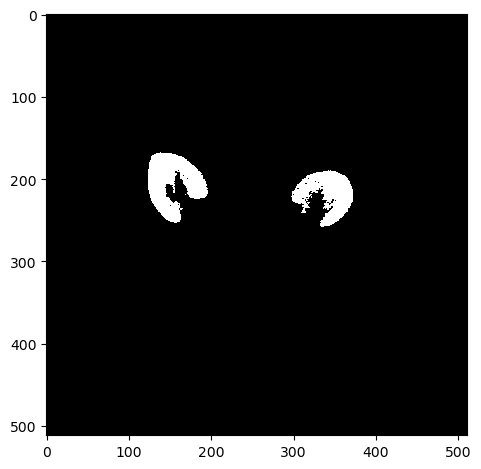

/tmp/ipykernel_30749/115133715.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(closing)
/tmp/ipykernel_30749/115133715.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


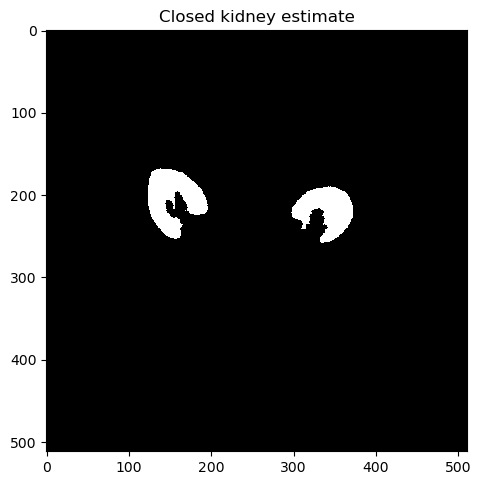

Answer: Found HU median 165
Number of labels: 2
Area 3560.0
Area 2975.0
Answer: Total area 40 cm^2
Answer: DICE score 0.911


In [72]:
# Create binary image from the filtered label image
i_kidney = label_img_filter > 0
io.imshow(i_kidney)
io.show()

footprint = disk(3)
closing = morphology.binary_closing(i_kidney, footprint)
io.imshow(closing)
plt.title("Closed kidney estimate")
io.show()
kidney_estimate = closing

hu_values = im[kidney_estimate]
med_hu = np.median(hu_values)
print(f"Answer: Found HU median {med_hu:.0f}")

label_img = measure.label(kidney_estimate)
n_labels = label_img.max()
print(f"Number of labels: {n_labels}")
region_props = measure.regionprops(label_img)
sum_area = 0
for region in region_props:
    a = region.area
    print(f"Area {a}")
    sum_area += a

# Voxel side in cm
voxel_side = 0.78 / 10
sum_area = sum_area * voxel_side * voxel_side
print(f"Answer: Total area {sum_area:.0f} cm^2")

# Ground truth
gt_kidney = io.imread(in_dir + "kidneys_gt.png")
gt_kidney = gt_kidney > 0

dice_score = 1 - distance.dice(kidney_estimate.ravel(), gt_kidney.ravel())
print(f"Answer: DICE score {dice_score:.3f}")

# Traffic jam
Your company has been awarded a tender by the Danish Ministry of Transportation to
analyze traffic jams on the M3 motorway. Traffic cameras near the exit for the Technical
University of Denmark have recorded unusual afternoon traffic patterns, with heavy
congestion in the mornings but not in the afternoons.
The Ministry has provided a dataset for analysis. The files contains three features:
density (number of cars), speed (Km/h), and weather (labeled as "0" for a blue sky and
"1" for rain).
In the file, traffic_train.txt the first 140 rows are from morning traffic and the remaining
140 rows are from afternoon traffic.
In the file, traffic_test.txt the first 60 rows are from morning traffic and the remaining
60 rows are from afternoon traffic.

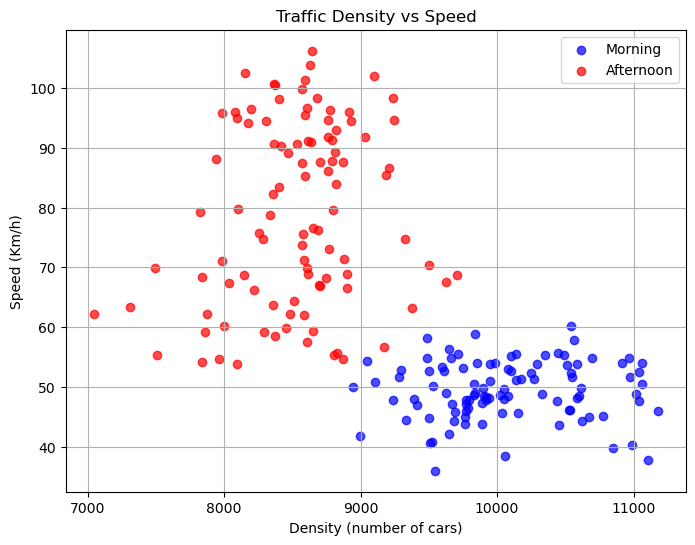

In [11]:
import numpy as np

# Load training data
in_dir = "traffic/"
data = np.loadtxt(in_dir + "traffic_train.txt", delimiter=",")  # Adjust delimiter if needed

# Extract features: density (col 0), speed (col 1), weather (col 2)
# Morning traffic: first 140 rows, take first 100
morning_data = data[:100, :2]  # Rows 0–99, columns 0–1 (density, speed)
# Afternoon traffic: rows 140–279, take first 100 (rows 140–239)
afternoon_data = data[140:240, :2]  # Rows 140–239, columns 0–1

# Data for scatter plot
morning_density = morning_data[:, 0]
morning_speed = morning_data[:, 1]
afternoon_density = afternoon_data[:, 0]
afternoon_speed = afternoon_data[:, 1]
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(morning_density, morning_speed, color='blue', label='Morning', alpha=0.7)
plt.scatter(afternoon_density, afternoon_speed, color='red', label='Afternoon', alpha=0.7)
plt.xlabel('Density (number of cars)')
plt.ylabel('Speed (Km/h)')
plt.title('Traffic Density vs Speed')
plt.legend()
plt.grid(True)
plt.show()

To detect traffic jams, you use a Fisher's Linear Discriminant Analysis
(LDA) model. The training set consists of the the samples in
traffic_train.txt. The model is trained using two features: density and
speed.
The trained LDA model is then applied to the test dataset traffic_test.txt.

In [12]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Load datasets (assume space-separated, adjust delimiter if needed)
in_dir = "traffic/"
try:
    train_data = np.loadtxt(in_dir + "traffic_train.txt", delimiter=",")
    test_data = np.loadtxt(in_dir + "traffic_test.txt", delimiter=",")
except FileNotFoundError:
    print(
        "Error: Dataset files not found. Please ensure 'traffic_train.txt' and 'traffic_test.txt' are in the working directory."
    )
    exit()

# Extract features (density, speed) and labels
# Training set: 280 samples (140 morning, 140 afternoon)
X_train = train_data[:, :2]  # Columns 0 (density), 1 (speed)
y_train = np.array([1] * 140 + [2] * 140)  # Class 1 (morning), Class 2 (afternoon)

# Test set: 120 samples (60 morning, 60 afternoon)
X_test = test_data[:, :2]  # Columns 0 (density), 1 (speed)
y_test = np.array([1] * 60 + [2] * 60)  # Class 1 (morning), Class 2 (afternoon)

# Initialize and train LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Predict on test set
y_pred = lda.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print results
print(f"Test Set Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print("[[True Morning, False Afternoon]")
print(" [False Morning, True Afternoon]]")
print(conf_matrix)

Test Set Accuracy: 0.9167

Confusion Matrix:
[[True Morning, False Afternoon]
 [False Morning, True Afternoon]]
[[59  1]
 [ 9 51]]


How many afternoon samples were classified as morning samples,
indicating slowed, high-density traffic (i.e., traffic jams)
ANS: 9

To get an impression of the weathers influence on the traffic you count
the number of days where there was rain in the morning in the training
set. How many days?

In [13]:
train_data = np.loadtxt(in_dir + "traffic_train.txt", delimiter=",")
train_data.shape
morning_data_weather = train_data[:100, -1]  
unique, counts = np.unique(morning_data_weather, return_counts=True)
dict(zip(unique, counts))

{np.float64(0.0): np.int64(55), np.float64(1.0): np.int64(45)}

## ANS: Between 35 and 45

You are asked to design a system that can track skiers on a ski slope. Due
to the weather, you can expect that the lightning conditions slowly
changes during the slope opening times. What elements do you need in
your image analysis system? \
Ans: Estimation of a slowly changing background image, computing difference
between current video frame and background, detection of significant
changes in the image, analysis of moving objects.

# Screws
Your friend has renovated his apartment and all the screws and bolts is now all messed
up. She calls for your help to use machine vision to sort them. She also provides 20
example images of the screws and bolts that is in her box.
Perhaps principal component analysis (PCA) can be a part of the solution. Therefore
you start by computing an average photo of the collection and then use PCA
from sklearn.decomposition to compute the 7 principal components from the photos.
You also project all photos to the PCA spaces, so you have their positions in PCA space.

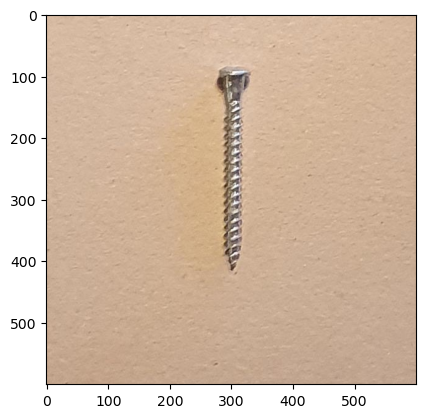

In [14]:
img = io.imread("screws/screws_000.jpg")
plt.imshow(img), img.shape
img_height = img.shape[0]
img_width = img.shape[1]
img_channels = img.shape[2]

In [15]:
def create_u_byte_image_from_vector(im_vec, height, width, channels):
    min_val = im_vec.min()
    max_val = im_vec.max()

    # Transform to [0, 1]
    im_vec = np.subtract(im_vec, min_val)
    im_vec = np.divide(im_vec, max_val - min_val)
    im_vec = im_vec.reshape(height, width, channels)
    im_out = img_as_ubyte(im_vec)
    return im_out

/tmp/ipykernel_30749/1221927512.py:40: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(mean_img)


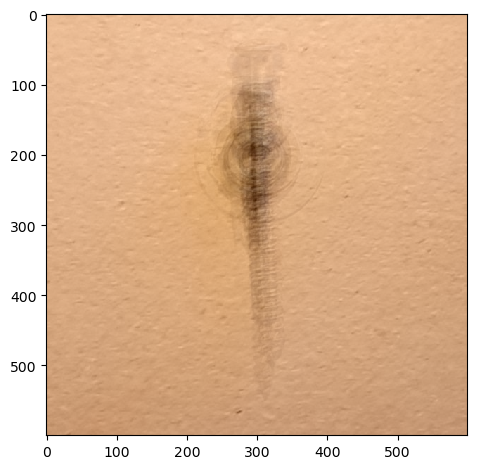

In [16]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

# Define image parameters (adjust based on actual images)
n_images = 20
n_components = 7  # Number of principal components
image_dir = "screws/"  # Directory with images

# Placeholder image file names (replace with actual paths)
image_files = [f"screws_{str(i).zfill(3)}.jpg" for i in range(n_images)]

# Load images into a data matrix
data_matrix = []
for file_name in image_files:
    file_path = os.path.join(image_dir, file_name)
    try:
        # Load image, convert to grayscale, resize if needed
        img = io.imread(file_path)
        # Flatten image to 1D array (100x100 = 10,000 pixels)
        img_array = np.array(img).flatten()
        data_matrix.append(img_array)
    except FileNotFoundError:
        print(f"Error: Image {file_path} not found. Please provide correct paths.")
        exit()

# Convert list to numpy array (20 images x 10,000 pixels)
data_matrix = np.array(data_matrix)  # Shape: (20, 10000)

# Compute the average image
average_image = np.mean(data_matrix, axis=0)  # Shape: (10000,)
mean_img = create_u_byte_image_from_vector(
    average_image,
    img_height,
    img_width,
    img_channels,
)
io.imshow(mean_img)

In [81]:
# Center the data (subtract mean from each image)
centered_data = data_matrix

# Apply PCA to compute 7 principal components
pca = PCA(n_components=n_components)
pca.fit(centered_data)

# Get the 7 principal components
principal_components = pca.components_  # Shape: (7, 10000)
explained_variance_ratio = (
    pca.explained_variance_ratio_
)  # Variance explained by each component

# Project images into PCA space
pca_coordinates = pca.transform(
    centered_data
)  # Shape: (20, 7), 7D coordinates for each image

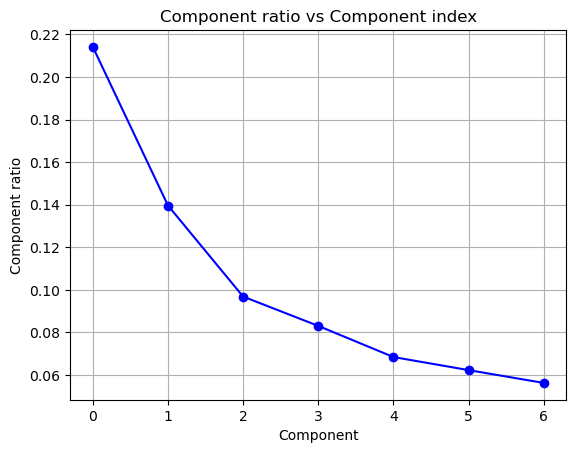

Explained Variance Ratio for 7 Principal Components:
[0.2141 0.1396 0.0968 0.0831 0.0685 0.0623 0.0563]


In [82]:
plt.plot(
    list(range(len(explained_variance_ratio))),
    explained_variance_ratio,
    marker="o",
    linestyle="-",
    color="b",
)
plt.title("Component ratio vs Component index")
plt.xlabel("Component")
plt.ylabel("Component ratio")
plt.grid(True)
plt.show()


# Print results
print("Explained Variance Ratio for 7 Principal Components:")
print(np.round(explained_variance_ratio, 4))

How many PCA components are needed to explain at least 44% of the
total variation in the set of photos?
Ans: 3

In [83]:
transformed_data = pca.transform(data_matrix)

It would be nice to group the screws and bolts together in boxes. Two do
that it is necessary to identify the ones that are most similar. First you try
to find the two photos that are most similar in PCA space, meaning the
two photos that have the smallest distance to each other in PCA space.

In [84]:
from scipy.spatial.distance import pdist, squareform

transformed_data = pca.transform(data_matrix)
# Compute pairwise Euclidean distances in PCA space
dist_matrix = squareform(pdist(transformed_data, metric='euclidean'))

# Ignore self-distances by setting the diagonal to infinity
np.fill_diagonal(dist_matrix, np.inf)

# Find indices of the two most similar photos (smallest distance)
min_idx = np.unravel_index(np.argmin(dist_matrix), dist_matrix.shape)
print(f"The two most similar photos are at indices: {min_idx[0]} and {min_idx[1]}")
print(f"Minimum distance in PCA space: {dist_matrix[min_idx]}")


The two most similar photos are at indices: 12 and 16
Minimum distance in PCA space: 1945.3988464868796


ANS: screws_012. jpg and screws_016.jpg

To get an idea of how mixed up the screws are you examine the positions
on the first principal component and show the two photos that have the
smallest and the largest value. 

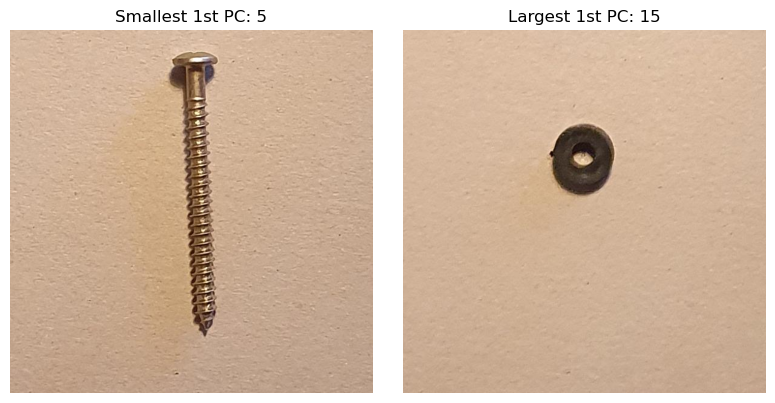

In [85]:
# Find indices of images with smallest and largest value on the first principal component
first_pc = transformed_data[:, 0]
min_pc_idx = np.argmin(first_pc)
max_pc_idx = np.argmax(first_pc)
indexes = [min_pc_idx, max_pc_idx]
in_dir = "screws/"
image_files = [f"screws_{str(idx).zfill(3)}.jpg" for idx in indexes]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(io.imread(in_dir + image_files[0]))
axes[0].set_title(f"Smallest 1st PC: {min_pc_idx}")
axes[0].axis("off")
axes[1].imshow(io.imread(in_dir + image_files[1]))
axes[1].set_title(f"Largest 1st PC: {max_pc_idx}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

To get an idea of the distances in PCA space, you select two photos
screws_007.jpg and screws_008.jpg and compute the Euclidean distance
between them in PCA space by using all the PCA coordinates. What is this
distance?

In [86]:
screw7_transformed = transformed_data[7, :]
screw8_transformed = transformed_data[8, :]
np.linalg.norm(screw7_transformed - screw8_transformed)

np.float64(20284.150806125843)

## ANS: Between 20000 and 25000

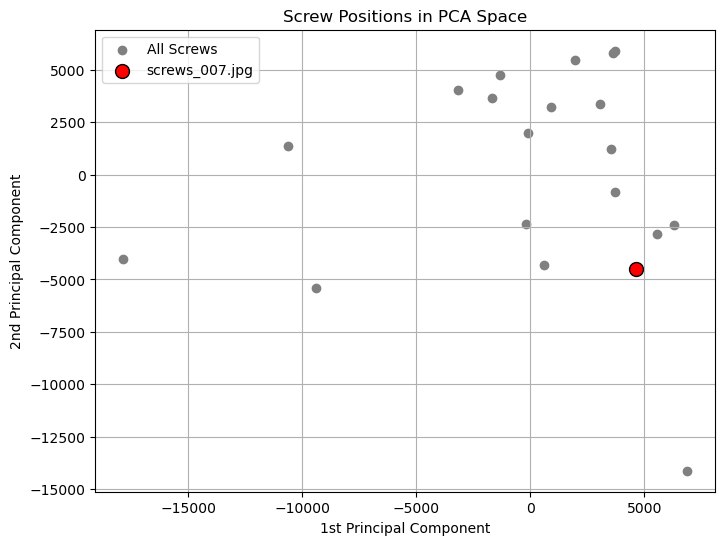

In [87]:
plt.figure(figsize=(8, 6))
plt.scatter(transformed_data[:, 0], transformed_data[:, 1], color='gray', label='All Screws')
plt.scatter(transformed_data[7, 0], transformed_data[7, 1], color='red', label='screws_007.jpg', s=100, edgecolor='black')
plt.xlabel('1st Principal Component')
plt.ylabel('2nd Principal Component')
plt.title('Screw Positions in PCA Space')
plt.legend()
plt.grid(True)
plt.show()

## ANS: NOt sure

# Gradient descent
You must find the optimal solution to a registration problem that spans a 2D parameter
space (x x ) . The cost function is defined as:
c = 7 ∗ x1 ∗ x1 + x1 ∗ x2 + 3 ∗ x2 ∗ x2 \
Since there is no analytic solution, you have selected a numerical optimization
approach based on the iterative gradient descent method. With the step size set to 0.1

Ans: 38

After 3 steps: x1 0.27 x2 0.36 c 1.00
After 4 steps: x1 -0.14 x2 0.12 c 0.17
After 5 steps: x1 0.05 x2 0.06 c 0.03
After 6 steps: x1 -0.02 x2 0.02 c 0.00
After 7 steps: x1 0.01 x2 0.01 c 0.00
After 8 steps: x1 -0.00 x2 0.00 c 0.00
After 9 steps: x1 0.00 x2 0.00 c 0.00
After 10 steps: x1 -0.00 x2 0.00 c 0.00
After 11 steps: x1 0.00 x2 0.00 c 0.00
After 12 steps: x1 -0.00 x2 0.00 c 0.00
After 13 steps: x1 0.00 x2 0.00 c 0.00


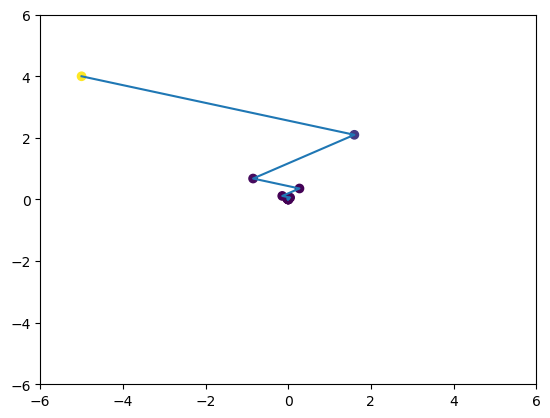

In [89]:
def gradient_descent_e_2024():
    x_1_start = -5
    x_2_start = 4
    step_length = 0.1

    n_steps = 13
    x_1 = x_1_start
    x_2 = x_2_start
    cs = []
    x_1_s = []
    x_2_s = []
    for i in range(n_steps):
        x_1_s.append(x_1)
        x_2_s.append(x_2)

        grad_x_1 = 14 * x_1 + x_2
        grad_x_2 = x_1 + 6 * x_2

        new_x_1 = x_1 - step_length * grad_x_1
        new_x_2 = x_2 - step_length * grad_x_2
        x_1 = new_x_1
        x_2 = new_x_2
        c = 7 * x_1 * x_1 + x_1 * x_2 + 3 * x_2 * x_2
        if c < 2.0:
            print(f"After {i+1} steps: x1 {x_1:.2f} x2 {x_2:.2f} c {c:.2f}")

        cs.append(c)
    # plt.plot(cs)
    # plt.show()

    plt.scatter(x_1_s, x_2_s, c=cs)
    plt.plot(x_1_s, x_2_s)
    plt.xlim([-6, 6])
    plt.ylim([-6, 6])
    plt.show()
gradient_descent_e_2024()

You monitor the value of the cost function, c. How many iterations is
needed before c is below 2.0 ?
Ans: 3

# Cells
A laboratory has collected two grey-scale images of tissue samples showing a Nissl
stain of cell nuclei appearing as bright spots in the images. The laboratory has asked
you for help to do different types of analysis of their cell images. \
There are two images: \
x_NisslStain_9-260.81.png \
y_NisslStain_9-260.81.png

\
An expert has manually identified five corresponding landmarks in the two images.
This provides us with two images where the landmarks are pixels with values 1 to 5. The rest of the pixels are 0.
You should find the (x, y) positions of the landmarks in the two images. The result
should be two lists of corresponding landmarks. The two images are called:
LabelsFixedImg.png
LabelsMovingImg.png

You have decided first applying a few pre-processing steps to identify cell
nuclei as individual binary objects. You do this by a BLOB analysis on the
two images:
x_NisslStain_9-260.81.png
y_NisslStain_9-260.81.png
The images can be made into binary images by setting of threshold of 30
and cleaned by applying a morphological opening with a disk-sized
structuring element of size 3. How many individual cells do you find in
the two images after the BLOB analysis (without removing BLOBS
touching the image border).

In [26]:
# Function to process one image and count BLOBs
def count_cell_nuclei(image_path, threshold=30, disk_radius=3):
    # Load image
    img = io.imread(image_path)

    # Ensure image is grayscale (if RGB, convert to grayscale)
    if len(img.shape) == 3:
        img = img.mean(axis=2).astype(img.dtype)

    # Step 1: Thresholding
    binary_img = (img >= threshold).astype(np.uint8)

    # Step 2: Morphological opening
    structuring_element = disk(disk_radius)
    cleaned_img = morphology.opening(binary_img, structuring_element)

    # Step 3: BLOB analysis
    labeled_img, num_blobs = label(
        cleaned_img, structure=np.ones((3, 3))
    )  # 8-connectivity

    return num_blobs

In [27]:
x_blobs = count_cell_nuclei("cells/x_NisslStain_9-260.81.png")
y_blobs = count_cell_nuclei("cells/y_NisslStain_9-260.81.png")

# Print results
print(f"Number of cell nuclei in x_NisslStain_9-260.81.png: {x_blobs}")
print(f"Number of cell nuclei in y_NisslStain_9-260.81.png: {y_blobs}")

Number of cell nuclei in x_NisslStain_9-260.81.png: 12
Number of cell nuclei in y_NisslStain_9-260.81.png: 12


## ANS: Between 10 and 15 cells per image

In [28]:
in_dir = "cells/"
fixed_img = io.imread(in_dir + "LabelsFixedImg.png")
moving_img = io.imread(in_dir + "LabelsMovingImg.png")
fixed_landmarks = []
moving_landmarks = []

# Find (x, y) coordinates for landmarks 1 to 5
for label in range(1, 6):
    # Fixed image
    y_fixed, x_fixed = np.where(fixed_img == label)
    if len(x_fixed) == 1:  # Expect exactly one pixel per landmark
        fixed_landmarks.append((x_fixed[0], y_fixed[0]))
    else:
        print(f"Warning: Landmark {label} in LabelsFixedImg has {len(x_fixed)} pixels")

    # Moving image
    y_moving, x_moving = np.where(moving_img == label)
    if len(x_moving) == 1:
        moving_landmarks.append((x_moving[0], y_moving[0]))
    else:
        print(
            f"Warning: Landmark {label} in LabelsMovingImg has {len(x_moving)} pixels"
        )
print("Fixed Image Landmarks (LabelsFixedImg.png):", fixed_landmarks)
print("Moving Image Landmarks (LabelsMovingImg.png):", moving_landmarks)
# Compute average landmark for each image
fixed_avg = np.mean(fixed_landmarks, axis=0)
moving_avg = np.mean(moving_landmarks, axis=0)

# Compute Euclidean distance between the two average landmarks
avg_distance = np.linalg.norm(np.array(fixed_avg) - np.array(moving_avg))
print(f"Euclidean distance between average landmarks: {avg_distance:.2f}")

Fixed Image Landmarks (LabelsFixedImg.png): [(np.int64(35), np.int64(107)), (np.int64(38), np.int64(73)), (np.int64(27), np.int64(31)), (np.int64(64), np.int64(52)), (np.int64(83), np.int64(50))]
Moving Image Landmarks (LabelsMovingImg.png): [(np.int64(2), np.int64(104)), (np.int64(21), np.int64(55)), (np.int64(44), np.int64(11)), (np.int64(74), np.int64(54)), (np.int64(96), np.int64(54))]
Euclidean distance between average landmarks: 7.28


## Ans: Between 6 and 8

You have developed a fully automatic system for finding cells in image.
The system is tested on an independent test image, where an expert has
marked the true cells. After evaluation of the results, it is found that:
18 cells are correctly found by the system
the system finds 7 objects that are not marked as cells by the expert
the system fails to find X cells that the expert has marked as cells
the system has a sensitivity of 0.82

Sensitivity = TP / (TP + FN)

To find the number of false negatives (FN), use the sensitivity formula:

Sensitivity = TP / (TP + FN)

Given:  
TP = 18  
Sensitivity = 0.82

So,  
0.82 = 18 / (18 + FN)  
18 + FN = 18 / 0.82  
FN = (18 / 0.82) - 18 ≈ 4

**Answer:**  
The system fails to find 4 cells that the expert has marked as cells.  
Sensitivity = 18 / (18 + 4) = 0.82
Between 2 and 5

# Game dice
A gaming company wishes to segment the eyes from a grayscale image depicting three
overlapping dice. The original image is CubesG.png.
An expert has manually drawn five regions of interest (ROIs) to train segmentation
models and has stored the pixel values for each ROI in separate text files.

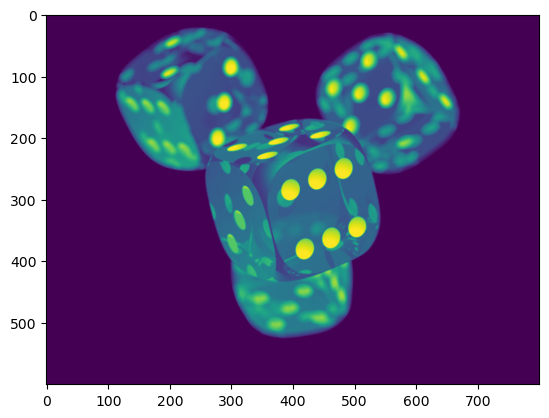

In [32]:
in_dir = "dice/"
A_roi = np.loadtxt(in_dir + "A_Cubes.txt", delimiter=" ")
B_roi = np.loadtxt(in_dir + "B_Cubes.txt", delimiter=" ")
C_roi = np.loadtxt(in_dir + "C_Cubes.txt", delimiter=" ")
D_roi = np.loadtxt(in_dir + "D_Cubes.txt", delimiter=" ")
E_roi = np.loadtxt(in_dir + "E_Cubes.txt", delimiter=" ")
original_img = io.imread(in_dir + "CubesG.png")
plt.imshow(original_img)

In [34]:
import numpy as np

def segment_dice_eyes(roi_data1, roi_data2, roi_data3, image_path='dice/CubesG.png'):
    """
    Read three ROI files, train a minimum distance classifier, and segment the dice eyes.
    
    Parameters:
    - roi_file1, roi_file2, roi_file3 (str): Paths to three ROI text files.
    - image_path (str): Path to the grayscale image (default: 'CubesG.png').
    
    Returns:
    - segmented (np.ndarray): Segmented image with pixel values {0, 50, 100, 150}.
    """
    
    # Load ROI data
    roi_data = [
        roi_data1, roi_data2, roi_data3
    ]
    
    # Compute class means
    class_means = [np.mean(data) if len(data) > 0 else 0 for data in roi_data]
    if any(len(data) == 0 for data in roi_data):
        raise ValueError("One or more ROI files contain no valid data.")
    
    # Load the grayscale image
    image = io.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image {image_path} not found or invalid.")
    
    # Segment the image
    height, width = image.shape
    segmented = np.zeros((height, width), dtype=np.uint8)
    output_intensities = {0: 50, 1: 100, 2: 150}  # Class visualization
    
    for i in range(height):
        for j in range(width):
            pixel = image[i, j]
            if pixel == 0:  # Background
                segmented[i, j] = 0
            else:
                distances = [abs(pixel - mean) for mean in class_means]
                class_idx = np.argmin(distances)
                segmented[i, j] = output_intensities[class_idx]
    
    return segmented

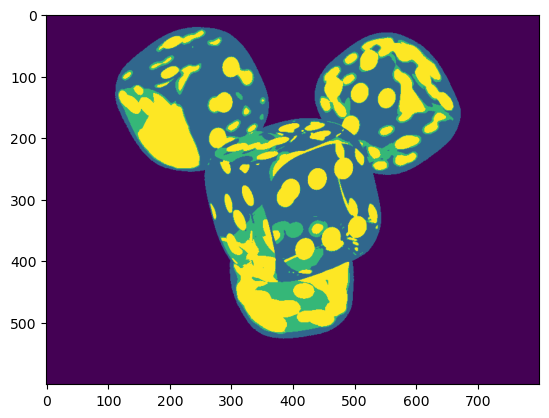

In [40]:
segment = segment_dice_eyes(B_roi, C_roi, D_roi)
plt.imshow(segment)

## ANs: B, C and D

A two class parametric classifier is trained using the values from ROI D
and ROI E. What is the optimal threshold between the two classes?

/tmp/ipykernel_30749/2833442383.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


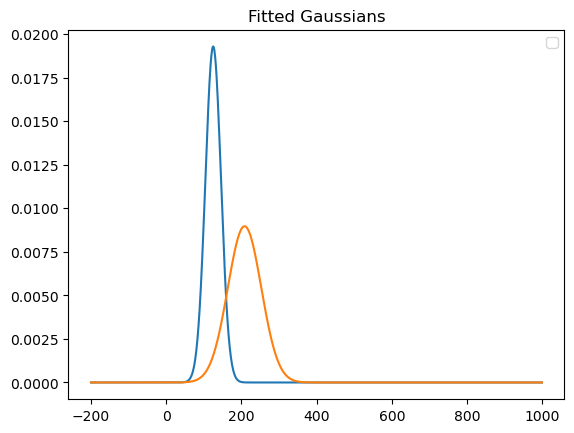

np.float64(166.58652781254906)

In [93]:
def get_gaussian_distributions(values, min_hu=-200, max_hu=1000):
    hu_range = np.arange(min_hu, max_hu, 1.0)
    mu = np.mean(values)
    std = np.std(values)
    pdf = norm.pdf(hu_range, mu, std)
    return pdf


def load_mask(mask_path):
    roi = io.imread(mask_path)
    mask = roi > 0
    return mask


def get_values(img, mask_path):
    mask = load_mask(mask_path)
    return img[mask]


min_hu, max_hu = -200, 1000
hu_range = np.arange(min_hu, max_hu, 1.0)
values = [D_roi, E_roi]
D_mean = np.mean(D_roi)
E_mean = np.mean(E_roi)
thres_1 = 0.5 * (D_mean + E_mean)

pdfs = [get_gaussian_distributions(value) for value in values]

for pdf in pdfs:
    plt.plot(hu_range, pdf)

plt.title("Fitted Gaussians")
plt.legend()
plt.show()
thres_1

Ans: Between 195 and 205

# Breast cancer
To be able to use image analysis to diagnose breast cancer, a sample dataset has been
created, where images of fine structures of breast tissues are provided together with
information about the patients cancer status. There are samples from patients with
without cancer (positive=1) and with cancer (negative=0).
For each patient a set of image features are computed and used in the further analysis.
Since the image features are probably correlated a principal component analysis is
performed to reduce the dimensions of the feature space.

In [46]:
import numpy as np
from sklearn.datasets import load_breast_cancer

# Step 1: Load the breast cancer dataset
breast = load_breast_cancer()
x = breast.data  # Features (30 features per observation)
target = breast.target  # Labels (0 = cancer, 1 = no cancer)

# Step 2: Scale the data (standardize: subtract mean, divide by std)
x_mean = np.mean(x, axis=0)
x_std = np.std(x, axis=0)
x_scaled = (x - x_mean) / x_std

# Step 3: Compute PCA using np.linalg.eig
# Compute the covariance matrix of the scaled data
cov_matrix = np.cov(x_scaled.T)  # Transpose to get features as variables

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues and eigenvectors in descending order
idx = np.argsort(eigenvalues)[::-1]  # Indices of sorted eigenvalues (descending)
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Step 4: Project the scaled data onto the PCA space
# Use all principal components (or select top k for dimensionality reduction)
x_pca = np.dot(x_scaled, eigenvectors)

# Optional: Print explained variance ratio to understand component importance
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
print("Explained variance ratio of each component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f}")

# Output the shape of the projected data
print(f"Shape of original data: {x.shape}")
print(f"Shape of PCA-projected data: {x_pca.shape}")

Explained variance ratio of each component:
PC1: 0.4427
PC2: 0.1897
PC3: 0.0939
PC4: 0.0660
PC5: 0.0550
PC6: 0.0402
PC7: 0.0225
PC8: 0.0159
PC9: 0.0139
PC10: 0.0117
PC11: 0.0098
PC12: 0.0087
PC13: 0.0080
PC14: 0.0052
PC15: 0.0031
PC16: 0.0027
PC17: 0.0020
PC18: 0.0018
PC19: 0.0016
PC20: 0.0010
PC21: 0.0010
PC22: 0.0009
PC23: 0.0008
PC24: 0.0006
PC25: 0.0005
PC26: 0.0003
PC27: 0.0002
PC28: 0.0001
PC29: 0.0000
PC30: 0.0000
Shape of original data: (569, 30)
Shape of PCA-projected data: (569, 30)


A PCA based classifier is tested by setting all samples that are projected
to a negative value on the first principal component to positive (without
cancer) and the rest to negative (with cancer).
How many samples are classified as positive (without cancer)?

In [94]:
# Get the first principal component (first eigenvector)
x_pc1 = x_pca[:, 0]

# Step 4: Project data onto the first principal component
# x_pc1 = np.dot(x_epca, pc1)

# Step 5: Classify samples
# Samples with negative PC1 projection are classified as positive (without cancer)
positive_samples = np.sum(x_pc1 < 0)

# Output the result
print(f"Number of samples classified as positive (without cancer): {positive_samples}")

Number of samples classified as positive (without cancer): 349


Ans: between 345 and 355

In [58]:
unique, counts = np.unique(target, return_counts=True)
dict(zip(unique, counts))
338/357

0.9467787114845938

Ans: between 0.90 and 1.0

In [97]:
is_true_positive = breast.target == 1
mean_pos = np.mean(x_pc1[is_true_positive])
mean_neg = np.mean(x_pc1[~is_true_positive])
print(f"Answer: Mean of true positive {mean_pos:.2f} and true negative {mean_neg:.2f}")


Answer: Mean of true positive -2.21 and true negative 3.71


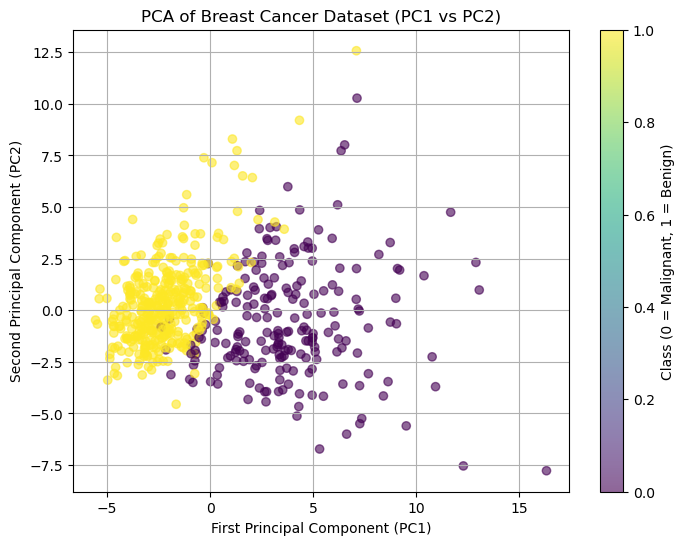

In [60]:
import matplotlib.pyplot as plt

# Plot the first two principal components, colored by the target labels
plt.figure(figsize=(8, 6))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=target, cmap="viridis", alpha=0.6)
plt.xlabel("First Principal Component (PC1)")
plt.ylabel("Second Principal Component (PC2)")
plt.title("PCA of Breast Cancer Dataset (PC1 vs PC2)")
plt.colorbar(scatter, label="Class (0 = Malignant, 1 = Benign)")
plt.grid(True)
plt.show()

Features=30, observations=569